# 03 – Cohort Analysis

## Purpose
This notebook groups leads by their entry month (cohort) and tracks conversion outcomes across the 24-month period. Cohort analysis reveals whether the firm's ability to convert leads is improving, declining, or stable over time and identifies which entry periods produced the highest-quality pipeline.

## Business Question addressed
- Which operational levers have the greatest impact on conversion?
- How do critical KPIs evolve over time?

## Outputs
1. Cohort conversion rate heatmap
2. Cohort size over time (lead volume by entry month)
3. Average deal value by cohort

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white', 'font.family': 'sans-serif', 'axes.spines.top': False, 'axes.spines.right': False})

# load cleaned data
leads = pd.read_csv('../data/processed/leads_clean.csv')
metrics = pd.read_csv('../data/processed/monthly_metrics.csv')

# parse dates
leads['entry_date'] = pd.to_datetime(leads['entry_date'])
leads['cohort'] = leads['entry_date'].dt.to_period('M')

print("Data loaded successfully")
print(f"leads: {leads.shape} | Date range: " f"{leads['entry_date'].min().date()} to "f"{leads['entry_date'].max().date()}")

Data loaded successfully
leads: (380, 11) | Date range: 2023-01-01 to 2024-12-23


In [91]:
# build cohort summary table
cohort_table = (leads.groupby('cohort').agg(total_leads=('lead_id', 'count'), total_converted=('converted', 'sum'), avg_deal_value=('deal_value', 'mean')).reset_index())

# Calculate conversion rate
cohort_table['conversion_rate'] = (cohort_table['total_converted'] / cohort_table['total_leads'] * 100).round(1)

# Format cohort as string for plotting
cohort_table['cohort_str'] = cohort_table['cohort'].astype(str)

print("Cohort table built successfully")
print(f"Total cohorts: {len(cohort_table)}")
display(cohort_table.head(8))

Cohort table built successfully
Total cohorts: 24


,cohort,total_leads,total_converted,avg_deal_value,conversion_rate,cohort_str
0,2023-01,24,10,3758.937500,41.7,2023-01
1,2023-02,21,6,3854.777778,28.6,2023-02
2,2023-03,23,6,3898.222222,26.1,2023-03
3,2023-04,13,1,3570.333333,7.7,2023-04
4,2023-05,16,7,3115.125000,43.8,2023-05
5,2023-06,8,1,3613.000000,12.5,2023-06
6,2023-07,8,1,4471.000000,12.5,2023-07
7,2023-08,16,1,4518.750000,6.2,2023-08


### Chart 1. Cohort conversion rate heatmap

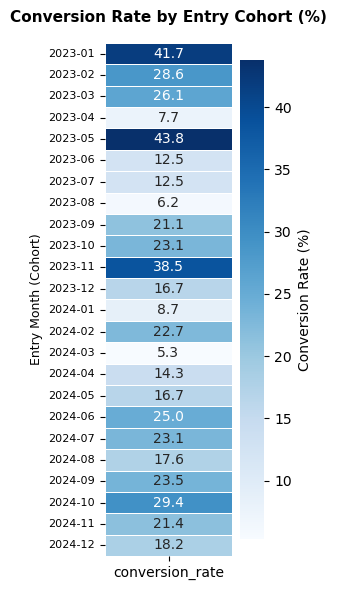

Cohort heatmap saved


In [92]:
# Prepare data for heatmap
heatmap_data = cohort_table.set_index('cohort_str')[['conversion_rate']]

fig, ax = plt.subplots(figsize=(3, 6))

sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='Blues', linewidths=0.5, linecolor='white', cbar_kws={'label': 'Conversion Rate (%)'}, ax=ax)

ax.set_title('Conversion Rate by Entry Cohort (%)', fontsize=11, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Entry Month (Cohort)', fontsize=9)
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('../reports/cohort_conversion_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Cohort heatmap saved")

### Chart 2. Cohort size over time 

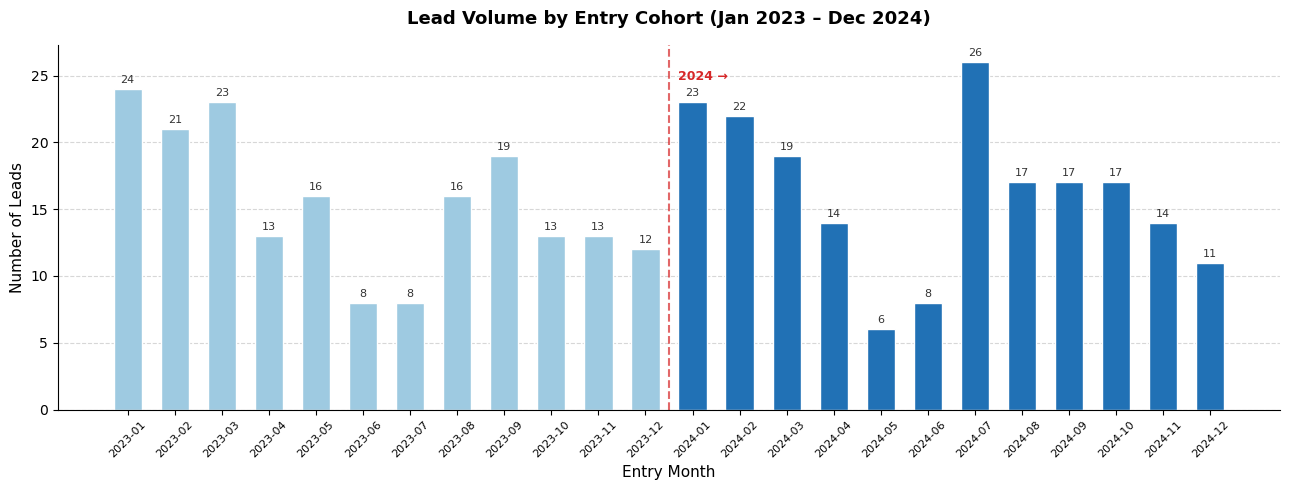

Cohort size chart saved


In [93]:
fig, ax = plt.subplots(figsize=(13, 5))

colors = ['#2171b5' if '2024' in str(c) 
    else '#9ecae1' 
    for c in cohort_table['cohort_str']]

bars = ax.bar(cohort_table['cohort_str'], cohort_table['total_leads'], color=colors, width=0.6, edgecolor='white')

# add value labels
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3, str(int(bar.get_height())), ha='center', va='bottom', fontsize=8, color='#333333')

# Add year separator line
ax.axvline(x=11.5, color='#d62728', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(11.7, cohort_table['total_leads'].max() * 0.95, '2024 →', color='#d62728', fontsize=9, fontweight='bold')

ax.set_title('Lead Volume by Entry Cohort (Jan 2023 – Dec 2024)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Entry Month', fontsize=11)
ax.set_ylabel('Number of Leads', fontsize=11)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('../reports/cohort_size_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Cohort size chart saved")

### Chart 3. Average deal value by cohort

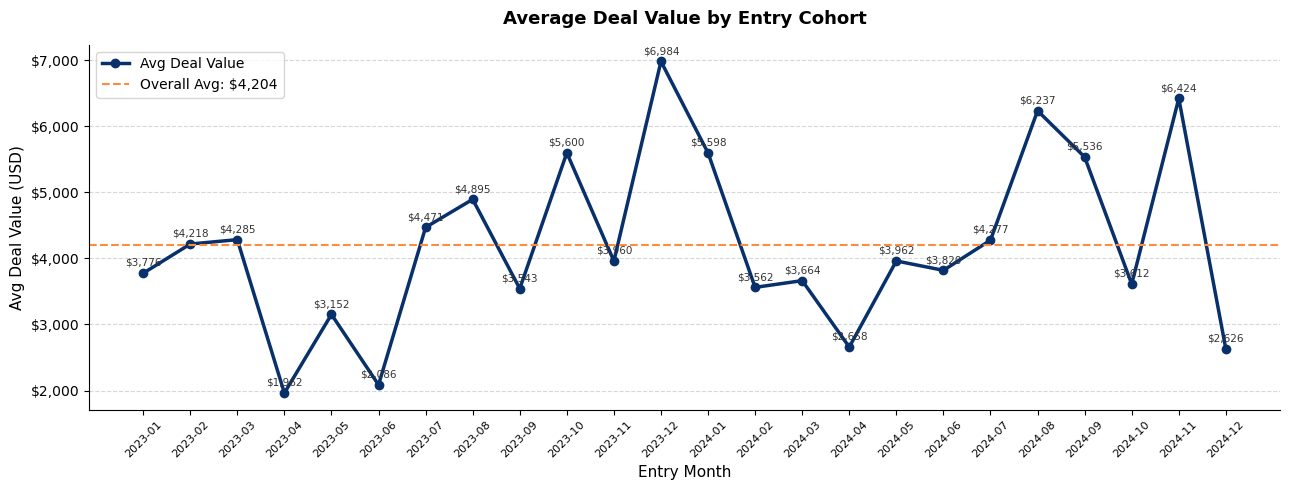

Deal value chart saved


In [94]:
# filter only converted leads with deal value
converted = leads[leads['converted'] == 1].copy()
converted['cohort_str'] = converted['cohort'].astype(str)

deal_by_cohort = (converted.groupby('cohort_str')['deal_value'].mean().round(0).reset_index())

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(deal_by_cohort['cohort_str'], deal_by_cohort['deal_value'], color='#08306b', linewidth=2.5, marker='o', markersize=6, label='Avg Deal Value')

# add overall average reference line
overall_avg = deal_by_cohort['deal_value'].mean()
ax.axhline(y=overall_avg, color='#fd8d3c', linestyle='--', linewidth=1.5, label=f'Overall Avg: ${overall_avg:,.0f}')

# add value labels on points
for _, row in deal_by_cohort.iterrows():
    ax.text(row['cohort_str'], row['deal_value'] + 80, f"${row['deal_value']:,.0f}", ha='center', va='bottom', fontsize=7.5, color='#333333')

ax.set_title('Average Deal Value by Entry Cohort', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Entry Month', fontsize=11)
ax.set_ylabel('Avg Deal Value (USD)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.legend(fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('../reports/cohort_deal_value.png',dpi=150, bbox_inches='tight')
plt.show()
print("Deal value chart saved")

### Summary table

In [95]:
# Final summary sorted by conversion rate
summary = cohort_table[['cohort_str', 'total_leads', 'total_converted', 'conversion_rate', 'avg_deal_value']].copy()

summary['avg_deal_value'] = summary['avg_deal_value'].apply(lambda x: f"${x:,.0f}" if pd.notna(x) else 'N/A')
summary.columns = ['Cohort', 'Total Leads', 'Converted', 'Conversion Rate (%)', 'Avg Deal Value']

print("=== Top 5 Cohorts by Conversion Rate ===")
display(summary.sort_values('Conversion Rate (%)', ascending=False).head(5))

print("\n=== Bottom 5 Cohorts by Conversion Rate ===")
display(summary.sort_values('Conversion Rate (%)', ascending=True).head(5))

=== Top 5 Cohorts by Conversion Rate ===


,Cohort,Total Leads,Converted,Conversion Rate (%),Avg Deal Value
4,2023-05,16,7,43.8,"$3,115"
0,2023-01,24,10,41.7,"$3,759"
10,2023-11,13,5,38.5,"$3,960"
21,2024-10,17,5,29.4,"$4,100"
1,2023-02,21,6,28.6,"$3,855"



=== Bottom 5 Cohorts by Conversion Rate ===


,Cohort,Total Leads,Converted,Conversion Rate (%),Avg Deal Value
14,2024-03,19,1,5.3,"$3,295"
7,2023-08,16,1,6.2,"$4,519"
3,2023-04,13,1,7.7,"$3,570"
12,2024-01,23,2,8.7,"$4,458"
5,2023-06,8,1,12.5,"$3,613"


## Cohort Analysis — Key Findings

### Chart 1 — Conversion Rate Heatmap
- The three highest-converting cohorts are 2023-05 (43.8%), 2023-01 (41.7%), and 2023-11 (38.5%). All coinciding with classic B2B budget cycle urgency windows: post-holiday, pre-summer, and pre-year-end
- These seasonal peaks did not repeat at the same intensity in 2024: Jan dropped from 41.7% to 8.7%, May from 43.8% to 16.7%, Nov from 38.5% to 21.4%
- Hypothesis: the firm may not be deploying proactive outreach strategies during historically high-conversion windows, a missed opportunity worth investigating.

### Chart 2 — Cohort Size Over Time
- 2024 generally brought higher or comparable lead volume versus 2023 with July 2024 peaking at 26 leads the highest single month in the dataset
- Despite higher volume, 2024 conversion rates were lower in most months confirming that volume and conversion quality move independently
- Key insight: the firm's best conversion periods were driven by lead quality and timing, not volume. Scaling lead generation without improving qualification may not improve revenue outcomes

### Chart 3 — Avg Deal Value by Cohort
- Dec 2023 recorded the highest avg deal value at $6,984 consistent with year-end budget flush behavior in B2B
- Dec 2024 dropped to $2,626: the lowest in the dataset suggesting the firm did not capture year-end high-value deals in 2024, a significant missed opportunity
- High-conversion months (2023-05 at 43.8%, 2023-11 at 38.5%) tend to show below-average deal values indicating faster closes on smaller, simpler engagements
- High-value months (Dec 2023, Aug 2024, Nov 2024) show lower conversion rates, consistent with longer, more complex negotiations for larger deals
- Nov 2024 is the strongest balanced cohort: 21.4% conversion rate combined with $6,424 avg deal value
- Key insight: conversion rate and deal value trade off against each other — the firm should define whether its strategy prioritizes volume of closes or value per deal, as optimizing for both simultaneously requires different operational approaches

### Overall Cohort Insight
- 2024 cohorts brought higher lead volume but lower conversion rates in most months compared to 2023. Volume growth did not translate to proportional revenue growth
- The firm's best combined performance (high conversion + high deal value) occurred in isolated months tied to fiscal calendar triggers — not as a consistent pattern
- A proactive calendar-based outreach strategy targeting Jan, May, Nov, and Dec could systematically capture the conversion and value peaks that currently appear only sporadically